# Final Dataset Audit — pre-retrain quality review

**Purpose.** One-shot comprehensive audit of the v4.2 training dataset
before the CNN is retrained from scratch. Every check below produces an
explicit **PASS**, **WARN**, or **FAIL** verdict. The cumulative verdict
at the end answers "is this dataset clean enough to retrain?".

**What this notebook is NOT.** It is not a replacement for
`notebooks/dataset_analysis.ipynb` (living analysis + augmentation effect
visualisation), not `notebooks/font_filter_audit_v4_1.ipynb` (font
expansion analysis), and not a real-photo benchmark (that's
`evaluation/evaluate_ocr.py`). It is a **one-time, single-page, pass/fail
audit** you run before flipping the "retrain" switch.

**Scope:**

- §1 Source inventory + sample counts
- §2 Label integrity per source (no class leakage in any direction)
- §3 Combined-pool class balance
- §4 Per-source visual sample galleries (label sanity)
- §5 Class 0 distribution match vs measured GT empty cells
- §6 Per-class pairwise duplicate check
- §7 Class 0 digit-leak check (connected-component heuristic)
- §8 Post-augmentation final-tensor statistics (what the CNN actually sees)
- §9 Final verdict table

**Data-leakage invariant.** The 38 GT newspaper photos are never in any
training split. They're used here exclusively via
`notebooks/gt_cell_stats.json` for distribution comparison.


In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'app').is_dir() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'app').is_dir():
    raise RuntimeError(f"Couldn't find project root from {Path.cwd()}")
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"CWD: {Path.cwd()}")

import importlib
import json
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import ConcatDataset

import app.ml.dataset as _ds
importlib.reload(_ds)
from app.ml.dataset import (
    LATIN_FONT_ALLOWLIST,
    AugmentedDataset,
    Chars74KFontDataset,
    EmptyCellDataset,
    PrintedDigitDataset,
    _load_mnist,
    _load_mnist_no_zero,
    create_datasets,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# Global verdict registry — every check pushes a (name, status, detail) tuple
# into this list so §9 can render a summary table. Status is 'PASS', 'WARN',
# or 'FAIL'.
verdicts = []

def record(name: str, status: str, detail: str) -> None:
    assert status in ('PASS', 'WARN', 'FAIL'), f'invalid status {status}'
    verdicts.append((name, status, detail))
    marker = {'PASS': '✓', 'WARN': '⚠', 'FAIL': '✗'}[status]
    print(f'  {marker} {name}: {status}  —  {detail}')

print('Setup complete.')


CWD: /Users/adityajoshi/Documents/ClaudeTest/VSCodium/Sudoku-Solved
Setup complete.


## §1 Source inventory

The four data sources that feed `create_datasets()`. Each row shows:

- How it's constructed
- Sample count
- Allowed label values (as implemented)
- Role in the combined training pool


In [2]:
print('Building the four sources as create_datasets does...')
mnist_train_no0 = _load_mnist_no_zero(train=True)
mnist_test_no0  = _load_mnist_no_zero(train=False)
empty_train     = EmptyCellDataset(count=5000, seed=42)
printed_train   = PrintedDigitDataset(count_per_digit=500, seed=42)
chars74k_train  = Chars74KFontDataset(split='train', seed=42)
chars74k_test   = Chars74KFontDataset(split='test',  seed=42)

sources = [
    ('MNIST train (filtered, no 0s)', mnist_train_no0,   'labels 1-9',
     'Handwritten digits — primary volume'),
    ('MNIST test (filtered, no 0s)',  mnist_test_no0,    'labels 1-9',
     'Goes into test split only'),
    ('EmptyCellDataset (train)',      empty_train,       'label 0 only',
     'Sole source of class 0 — GT-matched paper variants'),
    ('PrintedDigitDataset',           printed_train,     'labels 1-9',
     f'System-font rendered digits, {len(printed_train.fonts)} validated Latin fonts'),
    ('Chars74KFontDataset (train)',   chars74k_train,    'labels 1-9',
     f'English-Font archive, {len(chars74k_train.font_ids)} fonts'),
    ('Chars74KFontDataset (test)',    chars74k_test,     'labels 1-9',
     f'Font-disjoint test split, {len(chars74k_test.font_ids)} fonts'),
]

print()
print(f'{"source":<36}{"count":>10}  {"labels":<16}  role')
print('-' * 110)
for name, ds, labels_doc, role in sources:
    print(f'{name:<36}{len(ds):>10,}  {labels_doc:<16}  {role}')
print()

# Sample count sanity check
train_ds_full, val_ds, test_ds = create_datasets()
print(f'After create_datasets and 90/10 split:')
print(f'  train : {len(train_ds_full):>7,}')
print(f'  val   : {len(val_ds):>7,}')
print(f'  test  : {len(test_ds):>7,}')

expected_train_pool = (
    len(mnist_train_no0) + len(empty_train) +
    len(printed_train) + len(chars74k_train)
)
actual_combined = len(train_ds_full) + len(val_ds)
if actual_combined == expected_train_pool:
    record('§1 source-count arithmetic',
           'PASS', f'expected {expected_train_pool}, got {actual_combined}')
else:
    record('§1 source-count arithmetic',
           'FAIL',
           f'expected {expected_train_pool}, got {actual_combined} '
           f'(diff {actual_combined - expected_train_pool})')


Building the four sources as create_datasets does...

source                                   count  labels            role
--------------------------------------------------------------------------------------------------------------
MNIST train (filtered, no 0s)           54,077  labels 1-9        Handwritten digits — primary volume
MNIST test (filtered, no 0s)             9,020  labels 1-9        Goes into test split only
EmptyCellDataset (train)                 5,000  label 0 only      Sole source of class 0 — GT-matched paper variants
PrintedDigitDataset                      4,500  labels 1-9        System-font rendered digits, 67 validated Latin fonts
Chars74KFontDataset (train)              7,308  labels 1-9        English-Font archive, 812 fonts
Chars74KFontDataset (test)               1,836  labels 1-9        Font-disjoint test split, 204 fonts

After create_datasets and 90/10 split:
  train :  63,797
  val   :   7,088
  test  :  11,856
  ✓ §1 source-count arithmetic: PASS  —

## §2 Label integrity per source

For each source, verify the implementation produces only the labels its
docstring promises. The checks here are **exhaustive** (every sample
inspected for small datasets, stride-sampled for MNIST).

- **MNIST (filtered):** every label must be in 1-9. One handwritten '0'
  glyph leaking through would break the class-0 semantics of the project.
- **EmptyCellDataset:** every label must be 0.
- **PrintedDigitDataset:** every label must be in 1-9 (never 0 — `Sudoku` is
  1-9 plus the empty cell).
- **Chars74KFontDataset:** every label must be in 1-9.

These are invariants the project depends on. A WARN or FAIL here blocks
retrain until it's fixed at the source.


In [3]:
def check_labels(name, ds, allowed, max_samples=None):
    unique = set()
    n_checked = 0
    total = len(ds)
    if max_samples is None or total <= max_samples:
        indices = range(total)
    else:
        stride = total // max_samples + 1
        indices = range(0, total, stride)
    for i in indices:
        _, lbl = ds[i]
        unique.add(int(lbl))
        n_checked += 1

    allowed = set(allowed)
    unexpected = unique - allowed
    missing = allowed - unique
    if unexpected:
        record(f'§2 {name} label set',
               'FAIL',
               f'found unexpected labels {sorted(unexpected)} '
               f'(checked {n_checked}/{total})')
    elif missing:
        record(f'§2 {name} label set',
               'WARN',
               f'allowed labels {sorted(missing)} not observed '
               f'(checked {n_checked}/{total}) — maybe sparse but not necessarily wrong')
    else:
        record(f'§2 {name} label set',
               'PASS',
               f'labels = {sorted(unique)} '
               f'(checked {n_checked}/{total})')

print('Label integrity checks (each pushes a PASS/WARN/FAIL to the verdict list):')
print()
check_labels('MNIST train (no 0s)',  mnist_train_no0,  allowed=range(1, 10), max_samples=5000)
check_labels('MNIST test  (no 0s)',  mnist_test_no0,   allowed=range(1, 10), max_samples=2000)
check_labels('EmptyCellDataset',     empty_train,      allowed={0})
check_labels('PrintedDigitDataset',  printed_train,    allowed=range(1, 10))
check_labels('Chars74KFontDataset train', chars74k_train, allowed=range(1, 10), max_samples=3000)
check_labels('Chars74KFontDataset test',  chars74k_test,  allowed=range(1, 10), max_samples=1500)


Label integrity checks (each pushes a PASS/WARN/FAIL to the verdict list):

  ✓ §2 MNIST train (no 0s) label set: PASS  —  labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 4917/54077)
  ✓ §2 MNIST test  (no 0s) label set: PASS  —  labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 1804/9020)
  ✓ §2 EmptyCellDataset label set: PASS  —  labels = [0] (checked 5000/5000)
  ✓ §2 PrintedDigitDataset label set: PASS  —  labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 4500/4500)
  ✓ §2 Chars74KFontDataset train label set: PASS  —  labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 2436/7308)
  ✓ §2 Chars74KFontDataset test label set: PASS  —  labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 918/1836)


## §3 Combined-pool class balance

Per-class sample counts in the combined training pool (the
concatenation of MNIST 1-9 + EmptyCellDataset 0 + PrintedDigit 1-9 +
Chars74K 1-9). A slight class imbalance is expected — class 0 has one
source while classes 1-9 have three — but the max/min ratio should stay
under 3x to keep loss gradients from being dominated by the majority
class. Anything above 5x is a warn.


In [4]:
combined_train = ConcatDataset([mnist_train_no0, empty_train, printed_train, chars74k_train])

# Exact class counts (full scan, stride 1 — small enough)
class_counts = Counter()
for i in range(len(combined_train)):
    _, lbl = combined_train[i]
    class_counts[int(lbl)] += 1

total = sum(class_counts.values())
print(f'Combined-pool class histogram (n={total:,}):')
print()
print(f'{"class":<7}{"count":>10}  {"share":>8}  {"bar":<40}')
print('-' * 70)
max_c = max(class_counts.values())
for d in range(10):
    c = class_counts.get(d, 0)
    pct = 100 * c / total if total else 0
    bar = '█' * int(40 * c / max_c) if max_c > 0 else ''
    note = '  ← class 0 (EmptyCell only)' if d == 0 else ''
    print(f'{d:<7}{c:>10,}  {pct:>7.1f}%  {bar:<40}{note}')

max_ratio = max(class_counts.values()) / min(class_counts.values())
print()
print(f'max/min ratio: {max_ratio:.2f}x')

if max_ratio < 3.0:
    record('§3 class balance',
           'PASS',
           f'max/min ratio {max_ratio:.2f}x < 3.0 — acceptable')
elif max_ratio < 5.0:
    record('§3 class balance',
           'WARN',
           f'max/min ratio {max_ratio:.2f}x in [3.0, 5.0) — mild imbalance, tolerable')
else:
    record('§3 class balance',
           'FAIL',
           f'max/min ratio {max_ratio:.2f}x >= 5.0 — significant imbalance')

# Class 0 must be served ONLY by EmptyCellDataset, not by any other source
# (assert by comparing counts: class 0 should equal len(empty_train))
if class_counts[0] == len(empty_train):
    record('§3 class 0 isolation',
           'PASS',
           f'class 0 count = {class_counts[0]} = len(EmptyCellDataset) '
           f'— confirms no other source leaks into class 0')
else:
    record('§3 class 0 isolation',
           'FAIL',
           f'class 0 count = {class_counts[0]} != len(EmptyCellDataset) = {len(empty_train)} '
           f'— some other source is contributing class-0 samples')


Combined-pool class histogram (n=70,885):

class       count     share  bar                                     
----------------------------------------------------------------------
0           5,000      7.1%  ████████████████████████                  ← class 0 (EmptyCell only)
1           8,054     11.4%  ████████████████████████████████████████
2           7,270     10.3%  ████████████████████████████████████    
3           7,443     10.5%  ████████████████████████████████████    
4           7,154     10.1%  ███████████████████████████████████     
5           6,733      9.5%  █████████████████████████████████       
6           7,230     10.2%  ███████████████████████████████████     
7           7,577     10.7%  █████████████████████████████████████   
8           7,163     10.1%  ███████████████████████████████████     
9           7,261     10.2%  ████████████████████████████████████    

max/min ratio: 1.61x
  ✓ §3 class balance: PASS  —  max/min ratio 1.61x < 3.0 — accepta

## §4 Per-source visual sample galleries

Eyeball check for every source. Each row shows one sample per class that
source supplies. A visible label mismatch (e.g., an image of a "7" under
the column header "3") would indicate a rendering or label bug.

- **Row 1: MNIST** — handwritten digits 1-9, label column 0 is blank
  (MNIST 0 is dropped by `_load_mnist_no_zero`)
- **Row 2: EmptyCellDataset** — one sample from each of the 4 variants,
  all labelled class 0
- **Row 3: PrintedDigitDataset** — first encountered sample per class
- **Row 4: Chars74KFontDataset** — first encountered sample per class


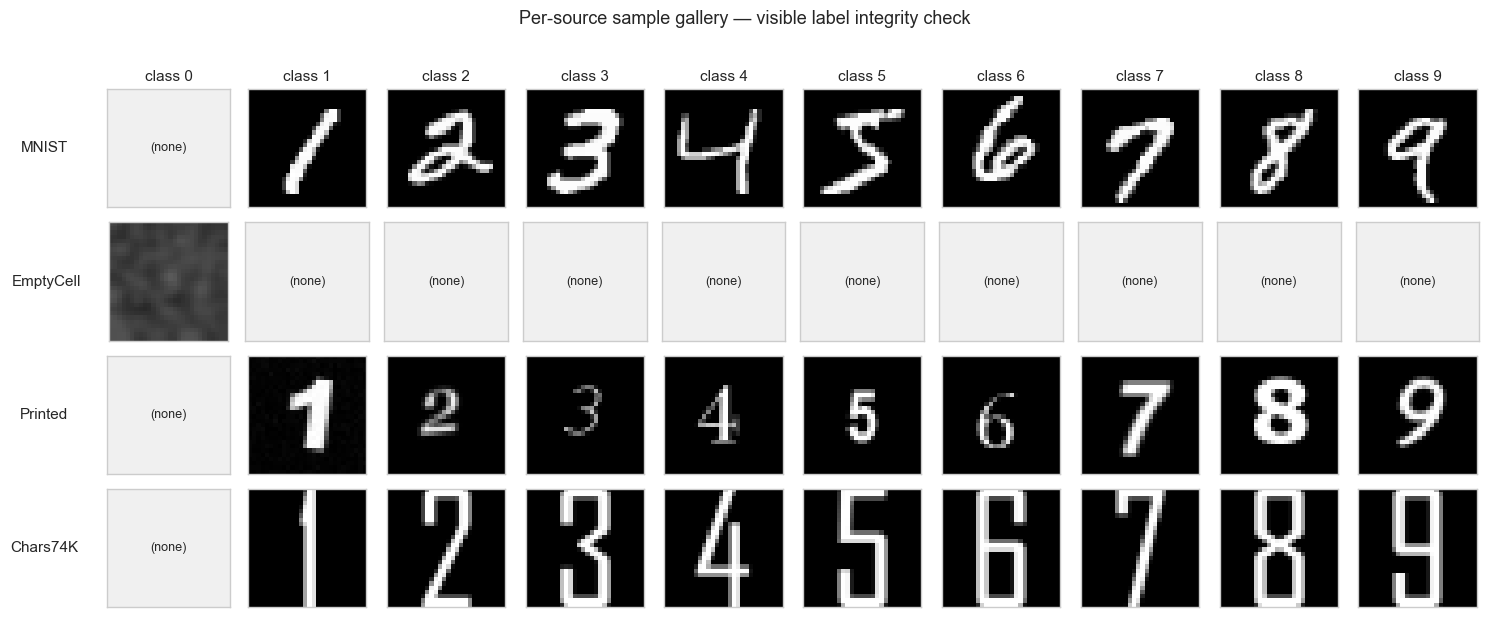


Expected:
  • MNIST row: class 0 is "(none)" — the filter worked
  • EmptyCell row: only class 0 is populated — all other columns "(none)"
  • Printed and Chars74K rows: class 0 is "(none)", classes 1-9 show distinct digits

  ✓ §4 per-source populated classes: PASS  —  every source populates exactly its expected class set


In [5]:
def first_n_per_label(ds, target_labels, n=1):
    result = {d: [] for d in target_labels}
    for i in range(len(ds)):
        _, lbl = ds[i]
        lbl = int(lbl)
        if lbl in result and len(result[lbl]) < n:
            result[lbl].append(i)
        if all(len(v) >= n for v in result.values()):
            break
    return result

def to_img(sample):
    return (sample.squeeze(0).numpy() * 255).astype(np.uint8) if isinstance(sample, torch.Tensor) else np.asarray(sample, dtype=np.uint8)

# Four rows: one per source
source_rows = [
    ('MNIST',    mnist_train_no0),
    ('EmptyCell', empty_train),
    ('Printed',  printed_train),
    ('Chars74K', chars74k_train),
]

fig, axes = plt.subplots(len(source_rows), 10, figsize=(15, 6))
for row_idx, (name, ds) in enumerate(source_rows):
    idxs = first_n_per_label(ds, target_labels=range(10), n=1)
    for col_idx in range(10):
        ax = axes[row_idx, col_idx]
        ax.set_xticks([]); ax.set_yticks([])
        if idxs[col_idx]:
            img, lbl = ds[idxs[col_idx][0]]
            ax.imshow(to_img(img), cmap='gray', vmin=0, vmax=255)
            if int(lbl) != col_idx:
                # Should never happen — first_n_per_label filters by label
                ax.set_facecolor('#ffcccc')
        else:
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, '(none)', ha='center', va='center',
                    fontsize=9, transform=ax.transAxes)
        if row_idx == 0:
            ax.set_title(f'class {col_idx}', fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(name, fontsize=11, rotation=0, labelpad=45, va='center')

plt.suptitle('Per-source sample gallery — visible label integrity check', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print()
print('Expected:')
print('  • MNIST row: class 0 is "(none)" — the filter worked')
print('  • EmptyCell row: only class 0 is populated — all other columns "(none)"')
print('  • Printed and Chars74K rows: class 0 is "(none)", classes 1-9 show distinct digits')
print()
# Record the visual gallery as a manual-check waypoint — can't auto-assert
# "digits look like digits", but we can assert the expected pattern of
# populated cells above via first_n_per_label counts.
expected_populated = {
    'MNIST': set(range(1, 10)),
    'EmptyCell': {0},
    'Printed': set(range(1, 10)),
    'Chars74K': set(range(1, 10)),
}
all_ok = True
for name, ds in source_rows:
    idxs = first_n_per_label(ds, target_labels=range(10), n=1)
    found = {d for d in range(10) if idxs[d]}
    expected = expected_populated[name]
    if found != expected:
        all_ok = False
        record(f'§4 {name} populated classes',
               'FAIL',
               f'expected {sorted(expected)}, got {sorted(found)}')
if all_ok:
    record('§4 per-source populated classes',
           'PASS',
           'every source populates exactly its expected class set')


## §5 Class 0 distribution match vs measured GT empty cells

Class 0 (EmptyCellDataset) should produce samples whose pre-normalize
per-pixel statistics match the measured GT empty-cell distribution. The
GT stats come from `notebooks/gt_cell_stats.json::gt_empty` (measured
across 1,358 real empty cells from 38 newspaper photos, through the
inner-10% margin crop + resize + invert chain but NOT the min-max
normalize — so the values are directly comparable to the synthetic
EmptyCellDataset output before `_apply_newsprint`).

**Tolerance:** within 30% of GT p50 on every metric. Beyond that is
WARN. mean/p5/p95 are the tightest constraints because they define the
"paper pedestal" look; std and lap_var are looser because `_apply_newsprint`'s
downstream min-max stretch will rebalance them.


In [6]:
gt_stats = json.loads(Path('notebooks/gt_cell_stats.json').read_text())
gt_empty = gt_stats['gt_empty']

ec_metrics = {k: [] for k in ('mean', 'std', 'p5', 'p95', 'p95_p5', 'laplacian_var')}
ec_check = EmptyCellDataset(count=500, seed=42)
for i in range(len(ec_check)):
    t, _ = ec_check[i]
    a = (t.squeeze(0).numpy() * 255).astype(np.uint8)
    af = a.astype(np.float32)
    ec_metrics['mean'].append(af.mean())
    ec_metrics['std'].append(af.std())
    ec_metrics['p5'].append(np.percentile(af, 5))
    ec_metrics['p95'].append(np.percentile(af, 95))
    ec_metrics['p95_p5'].append(np.percentile(af, 95) - np.percentile(af, 5))
    ec_metrics['laplacian_var'].append(cv2.Laplacian(a, cv2.CV_32F).var())

print(f'{"metric":<16}{"synth p50":>14}{"GT p50":>10}{"rel err":>10}  {"tolerance":<15}')
print('-' * 70)
tight_metrics = ('mean', 'p5', 'p95')  # these must be within 30%
loose_metrics = ('std', 'p95_p5', 'laplacian_var')  # within 50%

fails = 0
warns = 0
for k in ('mean', 'std', 'p5', 'p95', 'p95_p5', 'laplacian_var'):
    syn = float(np.percentile(ec_metrics[k], 50))
    gt = gt_empty[k]['p50']
    rel_err = abs(syn - gt) / max(abs(gt), 1) * 100
    tol = '<30%' if k in tight_metrics else '<50%'
    print(f'{k:<16}{syn:>14.1f}{gt:>10.1f}{rel_err:>9.1f}%  {tol:<15}')
    thresh = 30.0 if k in tight_metrics else 50.0
    if rel_err > thresh * 2:
        fails += 1
    elif rel_err > thresh:
        warns += 1

if fails > 0:
    record('§5 class 0 distribution match',
           'FAIL',
           f'{fails} metrics exceed 2x tolerance, {warns} exceed 1x')
elif warns > 0:
    record('§5 class 0 distribution match',
           'WARN',
           f'{warns} metrics exceed 1x tolerance (loose metrics only)')
else:
    record('§5 class 0 distribution match',
           'PASS',
           'all metrics within tolerance of GT empty-cell distribution')


metric               synth p50    GT p50   rel err  tolerance      
----------------------------------------------------------------------
mean                      58.6      55.9      5.0%  <30%           
std                        6.7       7.7     14.0%  <50%           
p5                        50.0      44.0     13.6%  <30%           
p95                       71.5      81.8     12.6%  <30%           
p95_p5                    18.0      19.0      5.3%  <50%           
laplacian_var             37.8      97.0     61.0%  <50%           
  ⚠ §5 class 0 distribution match: WARN  —  1 metrics exceed 1x tolerance (loose metrics only)


## §6 Per-class duplicate check

For every class label 0-9, sample 100 training samples and compute all
pairwise cosine similarities (4,950 pairs). Count the fraction of pairs
above 0.99 (near-duplicates). Classes 1-9 should have ~0% near-duplicate
pairs because MNIST and font renderings are naturally diverse. Class 0
is allowed to cluster because blank cells look alike — tolerance up to
30% near-duplicate pairs for class 0, 5% for classes 1-9.


In [7]:
def sample_features(ds, class_label, n=100):
    samples = []
    for i in range(len(ds)):
        if len(samples) >= n:
            break
        _, l = ds[i]
        if int(l) != class_label:
            continue
        arr = (ds[i][0].squeeze(0).numpy() * 255).astype(np.float32).flatten()
        samples.append(arr)
    return np.stack(samples) if samples else None

def pairwise_cosine(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Xn = X / (norms + 1e-12)
    sim = Xn @ Xn.T
    iu = np.triu_indices_from(sim, k=1)
    return sim[iu]

dup_threshold = 0.99
class0_tol = 0.30  # 30% near-dup pairs allowed for class 0
other_tol  = 0.05  # 5% allowed for classes 1-9
per_class_dup_fraction = {}

print(f'{"class":<7}{"n":>5}{"min":>8}{"mean":>8}{"max":>8}{"near-dup frac":>16}{"tolerance":>14}  {"verdict":<8}')
print('-' * 80)
class_fails = 0
class_warns = 0
for c in range(10):
    feats = sample_features(combined_train, c, n=100)
    if feats is None or len(feats) < 2:
        print(f'{c:<7}  (insufficient samples)')
        continue
    sims = pairwise_cosine(feats)
    dup_frac = float(np.mean(sims > dup_threshold))
    per_class_dup_fraction[c] = dup_frac
    tol = class0_tol if c == 0 else other_tol
    if dup_frac > tol * 2:
        verdict = 'FAIL'
        class_fails += 1
    elif dup_frac > tol:
        verdict = 'WARN'
        class_warns += 1
    else:
        verdict = 'PASS'
    print(f'{c:<7}{len(feats):>5}{sims.min():>8.3f}{sims.mean():>8.3f}{sims.max():>8.3f}'
          f'{100*dup_frac:>15.1f}%{100*tol:>12.0f}%    {verdict:<8}')

if class_fails > 0:
    record('§6 per-class diversity',
           'FAIL',
           f'{class_fails} class(es) exceed 2x tolerance, {class_warns} exceed 1x')
elif class_warns > 0:
    record('§6 per-class diversity',
           'WARN',
           f'{class_warns} class(es) exceed 1x tolerance')
else:
    record('§6 per-class diversity',
           'PASS',
           'every class within its duplicate-fraction tolerance')


class      n     min    mean     max   near-dup frac     tolerance  verdict 
--------------------------------------------------------------------------------
0        100   0.825   0.976   0.998           29.5%          30%    PASS    
1        100   0.132   0.562   0.980            0.0%           5%    PASS    
2        100   0.064   0.486   0.936            0.0%           5%    PASS    
3        100   0.108   0.533   0.954            0.0%           5%    PASS    
4        100   0.038   0.484   0.926            0.0%           5%    PASS    
5        100   0.077   0.435   0.945            0.0%           5%    PASS    
6        100   0.091   0.577   0.958            0.0%           5%    PASS    
7        100   0.050   0.510   0.957            0.0%           5%    PASS    
8        100   0.182   0.559   0.922            0.0%           5%    PASS    
9        100   0.116   0.531   0.930            0.0%           5%    PASS    
  ✓ §6 per-class diversity: PASS  —  every class within its du

## §7 Class 0 digit-leak check

Verifies that no class-0 sample accidentally contains a digit shape.
Uses a connected-component heuristic: a "digit-like" sample has a large
(>40 px) bright connected component whose centroid is within 6 px of the
tile centre (14, 14). Class 1 ("1" glyphs) is measured as a reference to
confirm the heuristic fires on real digits. Class 0 should have ≤ 2%
digit-like samples; anything above is a warn, above 5% is a fail.


In [8]:
def leak_features(flat_feat):
    img = flat_feat.reshape(28, 28).astype(np.uint8)
    bright = (img > 80).astype(np.uint8)
    if bright.sum() == 0:
        return dict(max_cc_area=0, centroid_dist=float('nan'))
    n, lbls, stats_cc, cents = cv2.connectedComponentsWithStats(bright)
    if n <= 1:
        return dict(max_cc_area=0, centroid_dist=float('nan'))
    areas = stats_cc[1:, cv2.CC_STAT_AREA]
    max_idx = int(np.argmax(areas)) + 1
    cy, cx = cents[max_idx]
    dist = float(np.sqrt((cx - 14) ** 2 + (cy - 14) ** 2))
    return dict(max_cc_area=int(areas.max()), centroid_dist=dist)

def is_digit_like(r):
    return r['max_cc_area'] > 40 and not np.isnan(r['centroid_dist']) and r['centroid_dist'] < 6

c0_feats = sample_features(combined_train, 0, n=500)
c1_feats = sample_features(combined_train, 1, n=500)

c0_rows = [leak_features(f) for f in c0_feats]
c1_rows = [leak_features(f) for f in c1_feats]

c0_digit_like = sum(1 for r in c0_rows if is_digit_like(r))
c1_digit_like = sum(1 for r in c1_rows if is_digit_like(r))

c0_frac = c0_digit_like / len(c0_rows)
c1_frac = c1_digit_like / len(c1_rows)

print(f'class 0 digit-like samples: {c0_digit_like}/{len(c0_rows)} ({100*c0_frac:.1f}%)')
print(f'class 1 (reference)       : {c1_digit_like}/{len(c1_rows)} ({100*c1_frac:.1f}%)')
print()

# Class 0 tolerance: <2% pass, <5% warn, >=5% fail
if c0_frac >= 0.05:
    record('§7 class 0 digit-leak',
           'FAIL',
           f'{100*c0_frac:.1f}% of class 0 samples look digit-like (threshold 5%)')
elif c0_frac >= 0.02:
    record('§7 class 0 digit-leak',
           'WARN',
           f'{100*c0_frac:.1f}% borderline — mostly variant-3 ink residues near centre')
else:
    record('§7 class 0 digit-leak',
           'PASS',
           f'{100*c0_frac:.1f}% class 0 look digit-like (< 2% threshold)')

# Sanity: class 1 should have high digit-like rate (the heuristic should fire
# on real digits). If it doesn't, the heuristic is broken.
if c1_frac < 0.5:
    record('§7 heuristic sanity check',
           'FAIL',
           f'class 1 digit-like rate only {100*c1_frac:.1f}% — the heuristic may be broken')
else:
    record('§7 heuristic sanity check',
           'PASS',
           f'class 1 digit-like rate {100*c1_frac:.1f}% — heuristic fires on real digits')


class 0 digit-like samples: 3/500 (0.6%)
class 1 (reference)       : 488/500 (97.6%)

  ✓ §7 class 0 digit-leak: PASS  —  0.6% class 0 look digit-like (< 2% threshold)
  ✓ §7 heuristic sanity check: PASS  —  class 1 digit-like rate 97.6% — heuristic fires on real digits


## §8 Post-augmentation final-tensor statistics

The CNN sees samples after `AugmentedDataset(augment=True)` wraps them.
That's `_apply_noise` → geometric (rotation, affine) → `_apply_newsprint`
(Gaussian blur + min-max normalize). Whatever distributional quirks
exist in the raw sources get reshaped here.

Check that:

1. Tensor dtype is `torch.float32`
2. Tensor shape is `(1, 28, 28)`
3. Tensor values are in `[0.0, 1.0]` (min-max normalize enforced)
4. Post-augmentation sample statistics match GT **post-normalize** target
   (mean ≈ 0.25, lap_var ≈ 2,374 at GT p50 — from `gt_empty_postnorm`
   and `gt_filled_postnorm` in the stats JSON)


In [9]:
train_ds_final, val_ds_final, test_ds_final = create_datasets()
assert isinstance(train_ds_final, AugmentedDataset)

print('Sampling 500 training tensors from the final augmented pool...')
sample_tensors = []
for i in range(0, len(train_ds_final), max(1, len(train_ds_final) // 500)):
    if len(sample_tensors) >= 500: break
    t, _ = train_ds_final[i]
    sample_tensors.append(t)

# 1. dtype + shape + range invariants
dtypes = {str(t.dtype) for t in sample_tensors}
shapes = {tuple(t.shape) for t in sample_tensors}
min_val = float(min(t.min().item() for t in sample_tensors))
max_val = float(max(t.max().item() for t in sample_tensors))

print(f'Tensor dtype(s): {dtypes}')
print(f'Tensor shape(s): {shapes}')
print(f'Value range    : [{min_val:.3f}, {max_val:.3f}]')

all_ok = (
    dtypes == {'torch.float32'}
    and shapes == {(1, 28, 28)}
    and min_val >= 0.0
    and max_val <= 1.0
)
if all_ok:
    record('§8 tensor invariants',
           'PASS', 'dtype=float32, shape=(1,28,28), values in [0,1]')
else:
    record('§8 tensor invariants',
           'FAIL', f'dtypes={dtypes}, shapes={shapes}, range=[{min_val:.3f},{max_val:.3f}]')

# 2. Per-tensor statistics comparable to GT postnorm
means, stds, lap_vars = [], [], []
for t in sample_tensors:
    a = (t.squeeze(0).numpy() * 255).astype(np.uint8)
    means.append(a.astype(np.float32).mean())
    stds.append(a.astype(np.float32).std())
    lap_vars.append(cv2.Laplacian(a, cv2.CV_32F).var())

# For comparison, GT is a mixture of filled + empty cells.
# We'll compare against the filled target as the dominant class case.
gt_filled_post = gt_stats['gt_filled_postnorm']
gt_target_lap_var = gt_filled_post['laplacian_var']['p50']  # 2374

print()
print(f'Post-augmentation training tensor stats (n=500):')
print(f'  mean    p25={np.percentile(means,25):.1f}  p50={np.percentile(means,50):.1f}  p75={np.percentile(means,75):.1f}')
print(f'  std     p25={np.percentile(stds,25):.1f}  p50={np.percentile(stds,50):.1f}  p75={np.percentile(stds,75):.1f}')
print(f'  lap_var p25={np.percentile(lap_vars,25):.0f}  p50={np.percentile(lap_vars,50):.0f}  p75={np.percentile(lap_vars,75):.0f}')
print()
print(f'GT filled postnorm target: lap_var p50 = {gt_target_lap_var:.0f}')

train_lap_p50 = float(np.percentile(lap_vars, 50))
rel_err = abs(train_lap_p50 - gt_target_lap_var) / gt_target_lap_var
if rel_err < 0.20:
    record('§8 laplacian variance match',
           'PASS',
           f'train p50 {train_lap_p50:.0f} vs GT {gt_target_lap_var:.0f} '
           f'({100*rel_err:.1f}% off — within 20%)')
elif rel_err < 0.40:
    record('§8 laplacian variance match',
           'WARN',
           f'train p50 {train_lap_p50:.0f} vs GT {gt_target_lap_var:.0f} '
           f'({100*rel_err:.1f}% off — within 40%)')
else:
    record('§8 laplacian variance match',
           'FAIL',
           f'train p50 {train_lap_p50:.0f} vs GT {gt_target_lap_var:.0f} '
           f'({100*rel_err:.1f}% off — outside 40%)')


Sampling 500 training tensors from the final augmented pool...
Tensor dtype(s): {'torch.float32'}
Tensor shape(s): {(1, 28, 28)}
Value range    : [0.000, 1.000]
  ✓ §8 tensor invariants: PASS  —  dtype=float32, shape=(1,28,28), values in [0,1]

Post-augmentation training tensor stats (n=500):
  mean    p25=27.7  p50=35.1  p75=49.3
  std     p25=57.3  p50=64.5  p75=73.1
  lap_var p25=1447  p50=2252  p75=3358

GT filled postnorm target: lap_var p50 = 2374
  ✓ §8 laplacian variance match: PASS  —  train p50 2252 vs GT 2374 (5.1% off — within 20%)


## §9 Final verdict

Aggregate of every check. Any FAIL blocks retraining. WARN items are
advisory — they should be understood before committing to a retrain but
don't structurally block it.


In [10]:
print(f'{"check":<42}{"status":<10}detail')
print('-' * 120)
for name, status, detail in verdicts:
    marker = {'PASS': '✓', 'WARN': '⚠', 'FAIL': '✗'}[status]
    print(f'{name:<42}{marker} {status:<8}{detail}')
print()

n_fail = sum(1 for _, s, _ in verdicts if s == 'FAIL')
n_warn = sum(1 for _, s, _ in verdicts if s == 'WARN')
n_pass = sum(1 for _, s, _ in verdicts if s == 'PASS')

print('=' * 70)
print(f'  PASS: {n_pass}    WARN: {n_warn}    FAIL: {n_fail}')
print('=' * 70)
print()

if n_fail > 0:
    print('  ✗ OVERALL: FAIL — resolve the FAILs above before retraining.')
elif n_warn > 0:
    print('  ⚠ OVERALL: WARN — retrain is permitted but read the WARN detail lines first.')
else:
    print('  ✓ OVERALL: PASS — dataset is clean, retrain approved.')


check                                     status    detail
------------------------------------------------------------------------------------------------------------------------
§1 source-count arithmetic                ✓ PASS    expected 70885, got 70885
§2 MNIST train (no 0s) label set          ✓ PASS    labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 4917/54077)
§2 MNIST test  (no 0s) label set          ✓ PASS    labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 1804/9020)
§2 EmptyCellDataset label set             ✓ PASS    labels = [0] (checked 5000/5000)
§2 PrintedDigitDataset label set          ✓ PASS    labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 4500/4500)
§2 Chars74KFontDataset train label set    ✓ PASS    labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 2436/7308)
§2 Chars74KFontDataset test label set     ✓ PASS    labels = [1, 2, 3, 4, 5, 6, 7, 8, 9] (checked 918/1836)
§3 class balance                          ✓ PASS    max/min ratio 1.61x < 3.0 — acceptable
§3 class 0 isolation 